# קישור לגיטאהב:https://github.com/naamaandadi2024/Project-part-2

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

C:\Users\97254\AppData\Local\Temp\ipykernel_32212\854447061.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset.csv')


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


In [3]:
from sklearn.base import BaseEstimator,TransformerMixin

In [4]:
print(df.info())
df['lead_actors_ids'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133884 entries, 0 to 133883
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           133884 non-null  object 
 1   primaryTitle     133884 non-null  object 
 2   startYear        133884 non-null  float64
 3   genres           131311 non-null  object 
 4   lead_actors_ids  123854 non-null  object 
 5   runtimeMinutes   133884 non-null  float64
 6   averageRating    115560 non-null  float64
 7   Language         55722 non-null   object 
 8   Country          53681 non-null   object 
 9   numVotes         124762 non-null  float64
 10  budget           16550 non-null   object 
 11  BoxOffice        17916 non-null   float64
 12  plot             59669 non-null   object 
dtypes: float64(5), object(8)
memory usage: 13.3+ MB
None


lead_actors_ids
[]                                                                     4731
['nm0040910', 'nm0793726', 'nm0535332', 'nm0206795', 'nm0766300']        12
['nm1001213']                                                             7
['nm0619107']                                                             7
['nm0190977']                                                             7
                                                                       ... 
['nm3638025', 'nm5261108', 'nm4684902', 'nm4547293', 'nm0414661']         1
['nm2659322', 'nm1173688', 'nm1397851', 'nm12161009', 'nm13935008']       1
['nm0549825', 'nm0930095', 'nm0402531', 'nm0719824', 'nm2492369']         1
['nm0015001', 'nm0015001', 'nm0015001', 'nm0481798', 'nm0419688']         1
nm0960033, nm0848968, nm0645634, nm0945290, nm1563697                     1
Name: count, Length: 118727, dtype: int64

In [5]:
df.columns

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot'],
      dtype='object')

### הורדת שורות עם משתנה מטרה חסר

In [6]:
df = df.dropna(subset=['averageRating'])

In [7]:
df = df.reset_index(drop=True)

In [8]:
print(df['averageRating'].max()) 

10.0


### y יצירת

In [9]:
y_train = df['averageRating']

### בדיקה כמה שחקנים "כוכבים" יש בכל סרט 

In [10]:
def count_actors(x):
    if pd.isna(x) or str(x).strip() == '' or str(x) == 'NaN':
        return 0
    try:
        return len(ast.literal_eval(x))
    except:
        return 0

df['lead_actors_ids'].apply(count_actors).value_counts()

lead_actors_ids
5    80340
0    21615
4     4709
3     3891
2     2533
1     2472
Name: count, dtype: int64

In [11]:
print(df['Country'].value_counts())

Country
United States                               18818
India                                        6794
United Kingdom                               2539
France                                       1685
Not Found                                    1645
                                            ...  
South Korea Germany                             1
Denmark   Germany   Sweden                      1
Belgium  Luxembourg  France                     1
Australia   New Zealand   United Kingdom        1
Japan [ 2 ]                                     1
Name: count, Length: 2511, dtype: int64


In [12]:
print(df.columns)

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot'],
      dtype='object')


In [13]:
print(df['Language'].value_counts().head(20))

Language
English       25718
Hindi          2295
French         2144
Spanish        1893
Italian        1756
Not Found      1645
Japanese       1441
Tamil          1157
German         1057
Telugu          996
Malayalam       962
Russian         757
Korean          670
Cantonese       524
Mandarin        490
Bengali         403
Kannada         395
Portuguese      374
Swedish         354
Polish          251
Name: count, dtype: int64


In [14]:
print(df['genres'].value_counts().head(20))

genres
Drama                             9255
['Drama']                         8088
Comedy                            4943
Documentary                       4217
['Comedy']                        3937
['Documentary']                   3428
Comedy,Drama                      2365
Drama,Romance                     2210
['Comedy', 'Drama']               1789
['Drama', 'Romance']              1714
Horror                            1470
Comedy,Romance                    1447
Comedy,Drama,Romance              1346
['Comedy', 'Romance']             1038
['Comedy', 'Drama', 'Romance']     997
['Horror']                         947
["Drama"]                          896
Thriller                           867
Crime,Drama                        804
Action,Crime,Drama                 786
Name: count, dtype: int64


In [15]:
print(df['genres'].unique())

['Crime,Drama,Thriller' 'Drama' 'Comedy' ... 'Biography,Family,Musical'
 'Adventure,Comedy,Sport' 'Action,Adult,Drama']


In [16]:
print(len(df))

115560


 ### בדיקה כמה ערכים חסרים יש בעמודת התקציב

In [17]:

missing_budget = df['budget'].isnull().sum()
print(f"מספר הערכים החסרים ב-budget: {missing_budget}")


missing_percentage = (df['budget'].isnull().sum() / len(df)) * 100
print(f"אחוז החסרים ב-budget: {missing_percentage:.2f}%")

מספר הערכים החסרים ב-budget: 99386
אחוז החסרים ב-budget: 86.00%


### prepare data שימוש בפונקציה 

In [18]:
def prepare_data(df_input):
    df = df_input.copy()
    import ast
    def count_actors(x):
         if pd.isna(x) or str(x).strip() == '' or str(x) == 'NaN':
            return 0
         try:
            return len(ast.literal_eval(x))
         except:
            return 0
   

   
    df['num_lead_actors'] = df['lead_actors_ids'].map(count_actors)
    
    df['duration_category'] = np.select(
        [
            (df['runtimeMinutes'] > 0) & (df['runtimeMinutes'] < 90),
            (df['runtimeMinutes'] >= 90) & (df['runtimeMinutes'] <= 130),
            (df['runtimeMinutes'] > 130)
        ],
        [0, 1, 2],
        default=np.nan
    )
    df['plot_word_count'] = df['plot'].apply(lambda x: len(str(x).split()) if pd.notna(x) else np.nan)

     
    clean_language = df['Language'].str.strip().str.title()
    df['is_english'] = np.where(clean_language == 'English', 1, 
                   np.where(clean_language.isna(), np.nan, 0))
    
    df['is_drama'] = np.select(
        [df['genres'].str.contains('Drama', na=False,case=False), df['genres'].notna() & ~df['genres'].str.contains('Drama', na=False)],
        [1, 0], default=np.nan
    )
    
    
    df['is_us'] = np.select(
    [
        (df['Country'] == 'United States') | 
        (df['Country'] == 'United States of America') | 
        (df['Country'] == 'USA') | 
        (df['Country'] == 'US')], [1], default=0)

    df['decade'] = (df['startYear'] // 10) * 10
  
   
    df = df.drop(columns=['numVotes', 'BoxOffice', 'tconst', 'primaryTitle', 'plot', 'Country', 'Language', 'genres','budget','averageRating'],errors='ignore')

    return df    

### הכנסת הטבלה לתוך הפונקציה

In [19]:
X_train = prepare_data(df)

print(X_train['num_lead_actors'].dtype)

int64


In [20]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115560 entries, 0 to 115559
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   startYear          115560 non-null  float64
 1   lead_actors_ids    109011 non-null  object 
 2   runtimeMinutes     115560 non-null  float64
 3   num_lead_actors    115560 non-null  int64  
 4   duration_category  115560 non-null  float64
 5   plot_word_count    56742 non-null   float64
 6   is_english         54050 non-null   float64
 7   is_drama           114714 non-null  float64
 8   is_us              115560 non-null  int32  
 9   decade             115560 non-null  float64
dtypes: float64(7), int32(1), int64(1), object(1)
memory usage: 8.4+ MB
None


In [21]:
df.columns

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot'],
      dtype='object')

In [22]:
X_train.columns

Index(['startYear', 'lead_actors_ids', 'runtimeMinutes', 'num_lead_actors',
       'duration_category', 'plot_word_count', 'is_english', 'is_drama',
       'is_us', 'decade'],
      dtype='object')

In [23]:
len(X_train)

115560

# בניית מחלקה חדשה שתיצור 3 עמודות חדשות בשביל למנוע זליגת מידע

 ### ActorExperienceTransformer : מחלקה

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin

class ActorExperienceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.actor_dict = None

    def fit(self, X, y=None):
        def safe_eval(x):
            if isinstance(x, list): return x
            try: return ast.literal_eval(x)
            except: return []

        actors_series = X['lead_actors_ids'].apply(safe_eval)
        actor_counts = actors_series.explode().value_counts()
        self.actor_dict = actor_counts.to_dict()
        return self

    def transform(self, X):
        X = X.copy()

        def get_cast_stats(actor_list_raw):
            if isinstance(actor_list_raw, list):
                actor_list = actor_list_raw
            elif isinstance(actor_list_raw, str):
                try:
                    actor_list = ast.literal_eval(actor_list_raw)
                except:
                    return np.nan, np.nan, np.nan
            else:
                return np.nan, np.nan, np.nan

            if not actor_list:
                return np.nan, np.nan, np.nan

            counts = [self.actor_dict.get(str(a).strip(), 0) for a in actor_list]
            
            return sum(counts) / len(counts), max(counts), sum(counts)

        stats = X['lead_actors_ids'].apply(get_cast_stats)
        X['avg_actor_experience'] = [s[0] for s in stats]
        X['max_actor_experience'] = [s[1] for s in stats]
        X['sum_actor_experience'] = [s[2] for s in stats]

        return X[['avg_actor_experience', 'max_actor_experience', 'sum_actor_experience']]

    def get_feature_names_out(self, input_features=None):
        return ['avg_actor_experience', 'max_actor_experience', 'sum_actor_experience']

### בדיקה אם עדיף למלא ערכים חסרים בממוצע או חציון

In [25]:

transformer = ActorExperienceTransformer()


transformer.fit(X_train)

ActorExperienceTransformer()

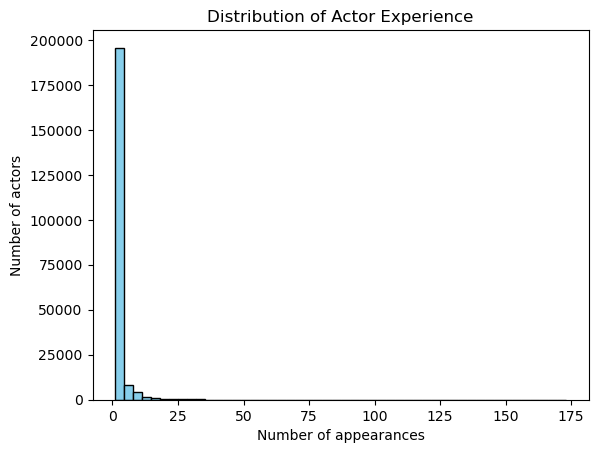

In [26]:
experience_values = list(transformer.actor_dict.values())

plt.hist(experience_values, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Actor Experience')
plt.xlabel('Number of appearances')
plt.ylabel('Number of actors')
plt.show()

### פיצול וטיפול בעמודות לפי סוגן

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [28]:
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent"))
])

In [29]:
actor_pipeline = Pipeline(steps=[
    ('actor_stats', ActorExperienceTransformer()), 
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                  
])

In [30]:
from sklearn.compose import ColumnTransformer

numeric_cols = ['startYear', 'runtimeMinutes', 'plot_word_count', 'decade', 'duration_category','num_lead_actors']
binary_cols = [ 'is_english', 'is_drama', 'is_us']

preprocessor = ColumnTransformer(transformers=[
    ('actor_stats', actor_pipeline, ['lead_actors_ids']),
    ('num', numeric_pipeline, numeric_cols),
    ('bin', binary_pipeline, binary_cols)
    ],
    verbose_feature_names_out=False
)

In [31]:
from sklearn.linear_model import ElasticNet

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet())
])

In [32]:
from sklearn.model_selection import KFold
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

### בדיקה מי הם הפרמטרים הטובים

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [34]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('actor_stats',
                                                                         Pipeline(steps=[('actor_stats',
                                                                                          ActorExperienceTransformer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['lead_actors_ids']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          Simple...
                                                                          'plot_word_count',
                                                                          'decade',
                                                                          'duration_category',
                                                                          'num_lead_actors']),
                                                                        ('bin',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent'))]),
                                                                         ['is_english',
                                                                          'is_drama',
                                                                          'is_us'])],
                                                          verbose_feature_names_out=False)),
                                       ('model', ElasticNet())]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.01, 0.1, 1, 10],
                         'model__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='neg_mean_squared_error')

In [35]:
results = pd.DataFrame(grid_search.cv_results_)
cols_to_show = ['param_model__alpha', 'param_model__l1_ratio', 'mean_test_score']
print(results[cols_to_show].sort_values(by='mean_test_score', ascending=False))

   param_model__alpha param_model__l1_ratio  mean_test_score
0                0.01                   0.1        -1.535683
1                0.01                   0.5        -1.536731
2                0.01                   0.9        -1.538751
3                 0.1                   0.1        -1.544939
4                 0.1                   0.5        -1.567629
5                 0.1                   0.9        -1.596333
6                   1                   0.1        -1.628561
7                   1                   0.5        -1.671360
8                   1                   0.9        -1.671360
9                  10                   0.1        -1.671360
10                 10                   0.5        -1.671360
11                 10                   0.9        -1.671360


### בדיקה נוספת למציאת הפרמטרים הטובים

In [36]:
param_grid_v2 = {
    'model__alpha': [ 0.1, 1, 10, 0.0009],
    'model__l1_ratio': [0.1, 0.9, 0.99,0.95]
}

grid_search_v2 = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid_v2,
    cv=cv_strategy,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_v2.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('actor_stats',
                                                                         Pipeline(steps=[('actor_stats',
                                                                                          ActorExperienceTransformer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['lead_actors_ids']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          Simple...
                                                                          'plot_word_count',
                                                                          'decade',
                                                                          'duration_category',
                                                                          'num_lead_actors']),
                                                                        ('bin',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent'))]),
                                                                         ['is_english',
                                                                          'is_drama',
                                                                          'is_us'])],
                                                          verbose_feature_names_out=False)),
                                       ('model', ElasticNet())]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.1, 1, 10, 0.0009],
                         'model__l1_ratio': [0.1, 0.9, 0.99, 0.95]},
             scoring='neg_mean_squared_error')

In [37]:
results_v2 = pd.DataFrame(grid_search_v2.cv_results_)
cols_to_show = ['param_model__alpha', 'param_model__l1_ratio', 'mean_test_score']
print(results_v2[cols_to_show].sort_values(by='mean_test_score', ascending=False))

   param_model__alpha param_model__l1_ratio  mean_test_score
12             0.0009                   0.1        -1.535525
13             0.0009                   0.9        -1.535541
15             0.0009                  0.95        -1.535544
14             0.0009                  0.99        -1.535546
0                 0.1                   0.1        -1.544939
1                 0.1                   0.9        -1.596333
3                 0.1                  0.95        -1.598189
2                 0.1                  0.99        -1.599751
4                   1                   0.1        -1.628561
5                   1                   0.9        -1.671360
6                   1                  0.99        -1.671360
7                   1                  0.95        -1.671360
8                  10                   0.1        -1.671360
9                  10                   0.9        -1.671360
10                 10                  0.99        -1.671360
11                 10   

### יצירת הפייפליין המלא עם הפרמטרים הכי טובים שנמצאו בבדיקות

In [38]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet(alpha=0.0009, l1_ratio=0.1))
])

# 3.3 
במודל הראשון

In [39]:
from sklearn.model_selection import cross_validate
scoring_metrics = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

scores = cross_validate(
    full_pipeline, X_train, y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

cv_results = pd.DataFrame(scores)
cv_results['test_RMSE'] = -cv_results['test_RMSE']
cv_results['test_MAE'] = -cv_results['test_MAE']

summary_table = pd.DataFrame({
    'Mean': cv_results[['test_RMSE', 'test_MAE', 'test_R2']].mean(),
    'Std_Dev': cv_results[['test_RMSE', 'test_MAE', 'test_R2']].std()
})

summary_table.index = ['RMSE', 'MAE', 'R2']

display(summary_table)

,Mean,Std_Dev
RMSE,1.239138,0.008291
MAE,0.965785,0.007145
R2,0.081149,0.004031


# 5.1

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

y_pred_enet = cross_val_predict(full_pipeline, X_train, y_train, cv=cv_strategy)
errors_enet = pd.DataFrame({
    'actual': y_train,
    'prediction': y_pred_enet,
    'error': y_pred_enet - y_train
}, index=X_train.index)

top_10_over_enet = errors_enet.sort_values(by='error', ascending=False).head(10)
top_10_under_enet = errors_enet.sort_values(by='error', ascending=True).head(10)

display(df.loc[top_10_over_enet.index])
display(df.loc[top_10_under_enet.index])

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
55959,tt2815138,Alien Valley,0.0,"['Horror', 'Mystery', 'Sci-Fi']","['nm3687341', 'nm7723072', 'nm7435462', 'nm194...",78.0,4.3,NaN,NaN,299.0,NaN,NaN,NaN
67980,tt1666348,Vixen Highway 2006: It Came from Uranus!,2010.0,"['Action', 'Horror', 'Thriller']","['nm1732299', ' nm1732299', ' nm2475997', ' nm...",250.0,1.2,NaN,NaN,150.0,NaN,NaN,NaN
106965,tt0330324,Ggamdong,1988.0,NaN,"nm0496894, nm1109595",118.0,1.2,NaN,NaN,16.0,NaN,NaN,NaN
114074,tt35197171,Gohare Siraf,2024.0,NaN,"nm12633996, nm3131645, nm3885550, nm3424920, n...",96.0,1.0,NaN,NaN,7.0,NaN,NaN,NaN
104797,tt3036740,Humshakals,2014.0,"Comedy,Drama,Romance","nm0451307, nm1299011, nm0438632, nm0060607, nm...",159.0,1.8,Hindi,India,9240.0,7.68,12.634,Ashok and Kumar are best friends. Shanaya and ...
105841,tt2988068,Homesick,2013.0,Drama,"nm5735816, nm5735815, nm1002746, nm5735814, nm...",98.0,1.2,NaN,NaN,65.0,NaN,NaN,NaN
111393,tt2344678,Himmatwala,2013.0,"Action,Comedy,Drama","nm0222426, nm1961459, nm0542498, nm0712546, nm...",150.0,1.8,Hindi,India,9713.0,8.16,8.264,"The story, set in 1983, begins with Ravi winni..."
57563,tt4960370,Alone Together,2014.0,"['Adventure', 'Drama', 'Music']",NaN,81.0,1.1,NaN,NaN,87.0,NaN,NaN,NaN
72305,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],[],99.0,1.2,NaN,NaN,105.0,NaN,NaN,NaN
4190,tt0015939,Idaho,1925.0,"Adventure,Drama,Western","['nm0358029', 'nm0723735', 'nm0089162', 'nm048...",200.0,1.9,Silent English intertitles,United States,26.0,NaN,NaN,NaN


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
1323,tt26689739,Il custode della memoria,2022.0,Documentary,"['nm14552290', 'nm12294185', 'nm14552293', 'nm...",67.0,9.8,NaN,NaN,32.0,NaN,NaN,NaN
75094,tt20779926,Zuena,2022.0,['Drama'],"['Emmanuel Kiti', 'George Kituto', 'Emmanuel M...",60.0,10.0,NaN,NaN,7.0,NaN,NaN,NaN
86923,tt34799007,Borderline Forever,2021.0,"['Adventure', 'Comedy', 'Fantasy']","['nm1268277', 'nm11596405', 'nm11596255', 'nm1...",64.0,9.7,NaN,NaN,122.0,NaN,NaN,NaN
86598,tt1541648,Budapest to Gettysburg,2007.0,"['Documentary', 'Family', 'History']","['nm0096872', 'nm1803743', 'nm0111232', 'nm012...",73.0,9.8,NaN,NaN,9.0,NaN,NaN,NaN
39081,tt21139706,Prince Oak Oakleyski and News Interviewers,2022.0,"Documentary,News,Reality-TV","['nm13776454', 'nm13776454', 'nm13776455', 'nm...",60.0,9.6,NaN,NaN,78.0,NaN,NaN,NaN
61912,tt22098258,Twenty One Pilots: Cinema Experience Extended Cut,2022.0,['Music'],"['nm5888677', 'nm5888678', 'nm12619696', 'nm12...",90.0,9.7,English,United States,129.0,175.0,749.2,Journey inside the minds of GRAMMY Award winni...
84758,tt28803600,Big Stages,2023.0,Documentary,"[""nm15265586"", ""nm15265589"", ""nm15265585"", ""nm...",65.0,9.6,Mandarin,China,28.0,NaN,109.5,Big World ( Chinese : 小小的我 ; pinyin : Xiǎo xiǎ...
65597,tt27170339,U poshukakh Skovorody,2022.0,['Documentary'],"['nm14663188', ' nm12949055', ' nm14058307', '...",76.0,9.7,NaN,NaN,6.0,NaN,NaN,NaN
2194,tt13110798,Il nostro paradiso,2020.0,Music,"['nm5494745', 'nm11907101', 'nm11907103', 'nm1...",70.0,9.5,NaN,NaN,29.0,NaN,NaN,NaN
202,tt1570358,Identity of the Soul,2009.0,Drama,"['nm0000603', 'nm3744109', 'nm3743762', 'nm374...",60.0,9.7,NaN,NaN,143.0,NaN,NaN,NaN


# אימון המודל 

In [41]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('actor_stats',
                                                  Pipeline(steps=[('actor_stats',
                                                                   ActorExperienceTransformer()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_actors_ids']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['startYear',
                                                   'runtimeMinutes',
                                                   'plot_word_count', 'decade',
                                                   'duration_category',
                                                   'num_lead_actors']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['is_english', 'is_drama',
                                                   'is_us'])],
                                   verbose_feature_names_out=False)),
                ('model', ElasticNet(alpha=0.0009, l1_ratio=0.1))])

### אותם סרטים מ5.1 פשוט לראות את הפיצרים שלהם

In [42]:
feature_names_enet = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

X_train_over_processed_enet = pd.DataFrame(
    full_pipeline[:-1].transform(X_train.loc[top_10_over_enet.index]),
    columns=feature_names_enet,
    index=top_10_over_enet.index
)

X_train_under_processed_enet = pd.DataFrame(
    full_pipeline[:-1].transform(X_train.loc[top_10_under_enet.index]),
    columns=feature_names_enet,
    index=top_10_under_enet.index
)

display(X_train_over_processed_enet)
display(X_train_under_processed_enet)

,avg_actor_experience,max_actor_experience,sum_actor_experience,startYear,runtimeMinutes,plot_word_count,decade,duration_category,num_lead_actors,is_english,is_drama,is_us
55959,-0.764452,-0.757809,-0.746060,-78.510349,-0.920630,-0.211728,-77.625043,-1.218459,0.600033,0.0,0.0,0.0
67980,-0.741098,-0.757809,-0.721775,0.492880,6.776204,-0.211728,0.660618,2.075189,0.600033,0.0,0.0,0.0
106965,-0.297377,-0.302496,-0.308923,-0.371832,0.869331,-0.211728,-0.507825,0.428365,-1.911313,0.0,1.0,0.0
114074,-0.297377,-0.302496,-0.308923,1.043151,-0.115147,-0.211728,1.050099,0.428365,-1.911313,0.0,1.0,0.0
104797,-0.297377,-0.302496,-0.308923,0.650100,2.704042,2.470862,0.660618,2.075189,-1.911313,0.0,1.0,0.0
105841,-0.297377,-0.302496,-0.308923,0.610795,-0.025649,-0.211728,0.660618,0.428365,-1.911313,0.0,1.0,0.0
111393,-0.297377,-0.302496,-0.308923,0.610795,2.301300,1.582361,0.660618,2.075189,-1.911313,0.0,1.0,0.0
57563,-0.297377,-0.302496,-0.308923,0.650100,-0.786383,-0.211728,0.660618,-1.218459,-1.911313,0.0,1.0,0.0
72305,-0.297377,-0.302496,-0.308923,-1.511680,0.019100,-0.211728,-1.676268,0.428365,-1.911313,0.0,0.0,0.0
4190,-0.600976,-0.606038,-0.576063,-2.848053,4.538752,-0.211728,-2.844710,2.075189,0.600033,0.0,1.0,1.0


,avg_actor_experience,max_actor_experience,sum_actor_experience,startYear,runtimeMinutes,plot_word_count,decade,duration_category,num_lead_actors,is_english,is_drama,is_us
1323,-0.717744,-0.656628,-0.697490,0.964541,-1.412869,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
75094,-0.764452,-0.757809,-0.746060,0.964541,-1.726113,-0.211728,1.050099,-1.218459,0.600033,0.0,1.0,0.0
86923,-0.787805,-0.808399,-0.770346,0.925236,-1.547117,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
86598,-0.787805,-0.808399,-0.770346,0.374965,-1.144375,-0.211728,0.271137,-1.218459,0.600033,0.0,0.0,0.0
39081,-0.717744,-0.757809,-0.697490,0.964541,-1.726113,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
61912,-0.787805,-0.808399,-0.770346,0.964541,-0.383642,-0.335606,1.050099,0.428365,0.600033,1.0,0.0,1.0
84758,-0.787805,-0.808399,-0.770346,1.003846,-1.502368,-0.190370,1.050099,-1.218459,0.600033,0.0,0.0,0.0
65597,-0.881220,-0.808399,-0.867487,0.964541,-1.010128,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
2194,-0.741098,-0.707219,-0.721775,0.885931,-1.278622,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
202,-0.274023,0.304587,-0.236067,0.453575,-1.726113,-0.211728,0.271137,-1.218459,0.600033,0.0,1.0,0.0


In [43]:
print(X_train_over_processed_enet.columns)

Index(['avg_actor_experience', 'max_actor_experience', 'sum_actor_experience',
       'startYear', 'runtimeMinutes', 'plot_word_count', 'decade',
       'duration_category', 'num_lead_actors', 'is_english', 'is_drama',
       'is_us'],
      dtype='object')


## סעיף 7

is_drama                0.312231
num_lead_actors        -0.266900
runtimeMinutes          0.205732
is_english             -0.143912
max_actor_experience   -0.128403
dtype: float64


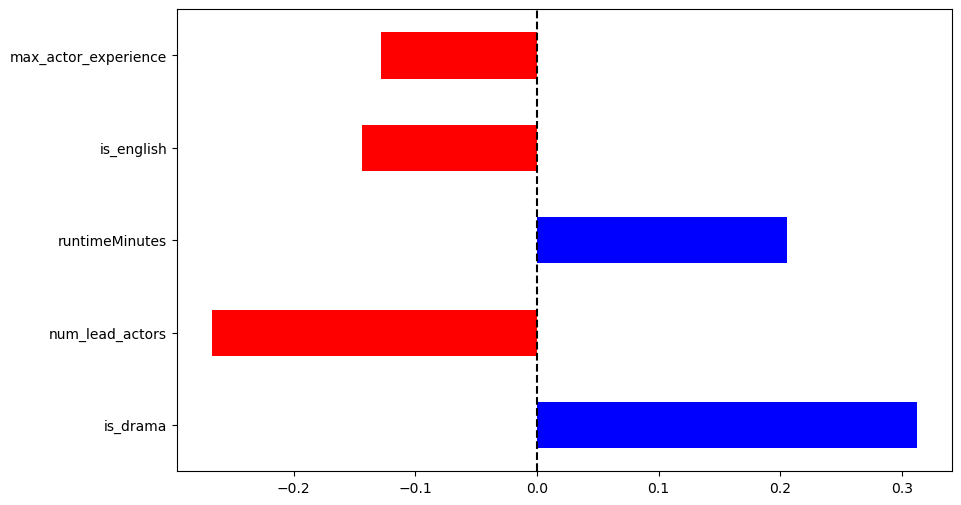

In [44]:
model_en = full_pipeline.named_steps['model']
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances_en = pd.Series(model_en.coef_, index=feature_names)

top_5_features = importances_en.reindex(importances_en.abs().sort_values(ascending=False).index).head(5)

print(top_5_features)

plt.figure(figsize=(10, 6))
colors = ['blue' if x > 0 else 'red' for x in top_5_features]
top_5_features.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# מודל שני

### ניסיון עם הפרמטרים שהוגדרו כברירת המחדל

In [45]:
from sklearn.ensemble import RandomForestRegressor


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

### FOLDS קבלת מדדים לפי

In [ ]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    rf_pipeline, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring=scoring_metrics, 
    return_train_score=False
)

cv_results = pd.DataFrame(scores)

cv_results['test_RMSE'] = -cv_results['test_RMSE']
cv_results['test_MAE'] = -cv_results['test_MAE']

print(cv_results[['test_RMSE', 'test_MAE', 'test_R2']].mean())
print(cv_results[['test_RMSE', 'test_MAE', 'test_R2']].std())

###  desicion tree ניסיון לראות מה יהיו תוצאות המדדים במודל מסוג

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [48]:
dt_scores = cross_validate(
    dt_pipeline, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring=scoring_metrics,
    return_train_score=False
)

dt_results = pd.DataFrame(dt_scores)
dt_results['test_RMSE'] = -dt_results['test_RMSE']
dt_results['test_MAE'] = -dt_results['test_MAE']

# הדפסת התוצאות להשוואה
print("Decision Tree Results:")
print(dt_results[['test_RMSE', 'test_MAE', 'test_R2']].mean())

Decision Tree Results:
test_RMSE    1.691723
test_MAE     1.300472
test_R2     -0.712625
dtype: float64


## לפי המדדים נמשיך לנסות לשפר את המודל 

### ניסיון לשנות את מודל העץ

In [49]:
 
rf_param_grid = {    
    'model__n_estimators': [50, 100, 120],
    'model__max_depth': [5, 10, 15]
}


grid_search_rf = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv_strategy, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train)

print("התוצאה הכי טובה של RF:", grid_search_rf.best_score_)

best_params = grid_search_rf.best_params_
print(f"הפרמטרים המנצחים שנמצאו הם: n_estimators={best_params['model__n_estimators']}, max_depth={best_params['model__max_depth']}")

התוצאה הכי טובה של RF: -1.4154513279444951
הפרמטרים המנצחים שנמצאו הם: n_estimators=120, max_depth=10


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=120, max_depth=10, random_state=42))
])

# 3.3

In [51]:
rf_scores = cross_validate(
    rf_pipeline2, X_train, y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

rf_results = pd.DataFrame(rf_scores)
rf_results['test_RMSE'] = -rf_results['test_RMSE']
rf_results['test_MAE'] = -rf_results['test_MAE']

rf_summary = pd.DataFrame({
    'Mean': rf_results[['test_RMSE', 'test_MAE', 'test_R2']].mean(),
    'Std_Dev': rf_results[['test_RMSE', 'test_MAE', 'test_R2']].std()
})

rf_summary.index = ['RMSE', 'MAE', 'R2']

print("Random Forest Results:")
display(rf_summary)

Random Forest Results:


,Mean,Std_Dev
RMSE,1.189700,0.008519
MAE,0.911545,0.007182
R2,0.153003,0.005278


## 5.1

In [52]:
y_pred_cv = cross_val_predict(rf_pipeline2, X_train, y_train, cv=cv_strategy)

rmse_from_cv_predict = np.sqrt(mean_squared_error(y_train, y_pred_cv))
print(f"RMSE from predictions: {rmse_from_cv_predict}")


errors_rf = pd.DataFrame({
    'actual': y_train,
    'prediction': y_pred_cv,
    'error': y_pred_cv - y_train
}, index=X_train.index)

top_10_over_rf = errors_rf.sort_values(by='error', ascending=False).head(10)
top_10_under_rf = errors_rf.sort_values(by='error', ascending=True).head(10)
print("Top 10 Overprediction:")

display(df.loc[top_10_over_rf.index])

print("Top 10 Underprediction:")

display(df.loc[top_10_under_rf.index])

RMSE from predictions: 1.1897274174971741
Top 10 Overprediction:


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
67980,tt1666348,Vixen Highway 2006: It Came from Uranus!,2010.0,"['Action', 'Horror', 'Thriller']","['nm1732299', ' nm1732299', ' nm2475997', ' nm...",250.0,1.2,NaN,NaN,150.0,NaN,NaN,NaN
63234,tt6935730,Trilogy of Bloody Guts,2015.0,['Horror'],NaN,60.0,1.2,English,United States,39.0,NaN,NaN,Three short films by Russian low budget movie ...
8633,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",['nm7368751'],70.0,1.0,NaN,NaN,422.0,NaN,NaN,NaN
69573,tt31451148,We Love Bad Boys,2024.0,Comedy,"['nm10466608', 'nm15878418', 'nm15857711', 'nm...",129.0,1.2,Telugu,India,3039.0,NaN,NaN,NaN
59113,tt5980526,Alien brainsuckers,2006.0,"['Comedy', 'Horror', 'Sci-Fi']",['nm8373591'],67.0,1.3,NaN,NaN,34.0,NaN,NaN,NaN
115239,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",NaN,64.0,1.0,NaN,NaN,6.0,NaN,NaN,NaN
81148,tt11536660,At the Back of the Screen,2020.0,"Documentary,Drama","['nm5687193', 'nm2478106', 'nm9526696', 'nm348...",188.0,1.5,English,United States,47.0,NaN,NaN,Take Back is a 2021 American action thriller f...
106053,tt22460554,Gaali Galoj,2022.0,Comedy,"nm1017494, nm10984632, nm0066075, nm15442694, ...",120.0,1.3,NaN,NaN,18.0,NaN,NaN,NaN
60471,tt6748034,Tribalism Is Killing Us,2019.0,['Documentary'],NaN,110.0,1.3,NaN,NaN,221.0,NaN,NaN,"Tribalism, racism, discrimination and losing w..."
64191,tt3506542,Tuberkulose,2007.0,"['Comedy', 'Horror']",NaN,63.0,1.6,NaN,NaN,23.0,NaN,NaN,NaN


Top 10 Underprediction:


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
5802,tt12958602,Il Santo Veleno,2023.0,Thriller,"['nm6228292', 'nm10185903', 'nm10091596', 'nm0...",77.0,9.4,NaN,NaN,12.0,NaN,NaN,NaN
91097,tt2450056,"Charlie, Trevor and a Girl Savannah",2015.0,"['Crime', 'Romance', 'Thriller']","['nm0388129', 'nm0000616', 'nm1738172', 'nm093...",93.0,8.5,English,United States,123.0,NaN,NaN,"Charlie, Trevor and a Girl Savannah is a thoug..."
34089,tt16436030,Puli Vachindi Meka Chachindi,2021.0,Thriller,"['nm13364623', 'nm4567542', 'nm14556287', 'nm0...",97.0,9.5,NaN,NaN,90.0,NaN,NaN,NaN
1384,tt35162929,Jefa De Jefas,2024.0,Action,"['nm4052191', 'nm2593355', 'nm8068275', 'nm140...",82.0,9.2,NaN,NaN,19.0,NaN,NaN,NaN
61912,tt22098258,Twenty One Pilots: Cinema Experience Extended Cut,2022.0,['Music'],"['nm5888677', 'nm5888678', 'nm12619696', 'nm12...",90.0,9.7,English,United States,129.0,175.0,749.2,Journey inside the minds of GRAMMY Award winni...
66778,tt5803828,Venganza Brutal,2016.0,['Crime'],"['nm2593355', ' nm4052191', ' nm4241366', ' nm...",90.0,9.3,NaN,NaN,20.0,NaN,NaN,NaN
102823,tt16740148,Hidden Agenda,2021.0,Drama,"nm13253614, nm13253618, nm13253634, nm13253630...",65.0,9.6,NaN,NaN,11.0,NaN,NaN,NaN
92107,tt6868594,Cabeza Madre,2017.0,['Comedy'],"['nm0004286', 'nm6698905', 'nm10071614', 'nm00...",88.0,9.2,NaN,NaN,32.0,NaN,NaN,"John, looking for the mother in Cuba he hasn't..."
27901,tt1796565,Night of Redemption,2010.0,['Adventure'],"['nm2339075', 'nm3106079', 'nm2346564', 'nm376...",90.0,9.2,NaN,NaN,8.0,NaN,NaN,NaN
2194,tt13110798,Il nostro paradiso,2020.0,Music,"['nm5494745', 'nm11907101', 'nm11907103', 'nm1...",70.0,9.5,NaN,NaN,29.0,NaN,NaN,NaN


In [53]:
display(top_10_over_rf)

display(top_10_under_rf)

,actual,prediction,error
67980,1.2,7.367183,6.167183
63234,1.2,7.203667,6.003667
8633,1.0,6.911729,5.911729
69573,1.2,7.020050,5.820050
59113,1.3,7.036954,5.736954
115239,1.0,6.719118,5.719118
81148,1.5,7.099216,5.599216
106053,1.3,6.885579,5.585579
60471,1.3,6.851776,5.551776
64191,1.6,7.148828,5.548828


,actual,prediction,error
5802,9.4,5.006274,-4.393726
91097,8.5,4.177341,-4.322659
34089,9.5,5.258140,-4.241860
1384,9.2,4.969741,-4.230259
61912,9.7,5.485971,-4.214029
66778,9.3,5.108216,-4.191784
102823,9.6,5.439033,-4.160967
92107,9.2,5.044094,-4.155906
27901,9.2,5.104645,-4.095355
2194,9.5,5.441500,-4.058500


## אימון המודל

In [54]:
rf_pipeline2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('actor_stats',
                                                  Pipeline(steps=[('actor_stats',
                                                                   ActorExperienceTransformer()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_actors_ids']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['startYear',
                                                   'runtimeMinutes',
                                                   'plot_word_count', 'decade',
                                                   'duration_category',
                                                   'num_lead_actors']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['is_english', 'is_drama',
                                                   'is_us'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=120,
                                       random_state=42))])

### הצגת הטבלאות של הסרטים עם השגיאה החמורה ביותר - אחרי אימון המודל 
### (בשביל להוציא את העמודות מהן המודל מנבא)

In [55]:
feature_names = rf_pipeline2.named_steps['preprocessor'].get_feature_names_out()

X_train_over_processed = pd.DataFrame(
    rf_pipeline2[:-1].transform(X_train.loc[top_10_over_rf.index]),
    columns=feature_names,
    index=top_10_over_rf.index
)

X_train_under_processed = pd.DataFrame(
    rf_pipeline2[:-1].transform(X_train.loc[top_10_under_rf.index]),
    columns=feature_names,
    index=top_10_under_rf.index
)

display(X_train_over_processed)
display(X_train_under_processed)

,avg_actor_experience,max_actor_experience,sum_actor_experience,startYear,runtimeMinutes,plot_word_count,decade,duration_category,num_lead_actors,is_english,is_drama,is_us
67980,-0.741098,-0.757809,-0.721775,0.492880,6.776204,-0.211728,0.660618,2.075189,0.600033,0.0,0.0,0.0
63234,-0.297377,-0.302496,-0.308923,0.689405,-1.726113,-0.331334,0.660618,-1.218459,-1.911313,1.0,0.0,1.0
8633,-0.787805,-0.808399,-0.867487,0.571490,-1.278622,-0.211728,0.660618,-1.218459,-1.409044,0.0,0.0,0.0
69573,-0.694390,-0.606038,-0.673204,1.043151,1.361571,-0.211728,1.050099,0.428365,0.600033,0.0,0.0,0.0
59113,-0.787805,-0.808399,-0.867487,0.335660,-1.412869,-0.211728,0.271137,-1.218459,-1.409044,0.0,0.0,0.0
115239,-0.297377,-0.302496,-0.308923,0.925236,-1.547117,-0.211728,1.050099,-1.218459,-1.911313,0.0,0.0,0.0
81148,-0.671037,-0.656628,-0.648919,0.885931,4.001764,-0.267259,1.050099,2.075189,0.600033,1.0,1.0,1.0
106053,-0.297377,-0.302496,-0.308923,0.964541,0.958829,-0.211728,1.050099,0.428365,-1.911313,0.0,0.0,0.0
60471,-0.297377,-0.302496,-0.308923,0.846626,0.511339,-0.365507,0.660618,0.428365,-1.911313,0.0,0.0,0.0
64191,-0.297377,-0.302496,-0.308923,0.374965,-1.591866,-0.211728,0.271137,-1.218459,-1.911313,0.0,0.0,0.0


,avg_actor_experience,max_actor_experience,sum_actor_experience,startYear,runtimeMinutes,plot_word_count,decade,duration_category,num_lead_actors,is_english,is_drama,is_us
5802,-0.647683,-0.606038,-0.624633,1.003846,-0.965379,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
91097,2.014641,4.908303,2.143901,0.689405,-0.249395,-0.309976,0.660618,0.428365,0.600033,1.0,0.0,1.0
34089,-0.600976,-0.555448,-0.576063,0.925236,-0.070398,-0.211728,1.050099,0.428365,0.600033,0.0,0.0,0.0
1384,-0.530914,-0.504857,-0.503206,1.043151,-0.741634,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0
61912,-0.787805,-0.808399,-0.770346,0.964541,-0.383642,-0.335606,1.050099,0.428365,0.600033,1.0,0.0,1.0
66778,-0.577622,-0.504857,-0.551777,0.728710,-0.383642,-0.211728,0.660618,0.428365,0.600033,0.0,0.0,0.0
102823,-0.297377,-0.302496,-0.308923,0.925236,-1.502368,-0.211728,1.050099,-1.218459,-1.911313,0.0,1.0,0.0
92107,-0.250670,0.304587,-0.211782,0.768016,-0.473140,-0.275803,0.660618,-1.218459,0.600033,0.0,0.0,0.0
27901,-0.577622,-0.504857,-0.551777,0.492880,-0.383642,-0.211728,0.660618,0.428365,0.600033,0.0,0.0,0.0
2194,-0.741098,-0.707219,-0.721775,0.885931,-1.278622,-0.211728,1.050099,-1.218459,0.600033,0.0,0.0,0.0


# 5.3

###  ? כמה מהסרטים חופפים



איחוד העשירייה הגבוהה ביותר והעשירייה הנמוכה ביותר(של כל מודל) + מציאת החפיפה (אינדקסים שמופיעים בשני המודלים)

In [56]:
outliers_enet = pd.concat([top_10_over_enet, top_10_under_enet])
outliers_rf = pd.concat([top_10_over_rf, top_10_under_rf])

overlap = set(outliers_enet.index).intersection(set(outliers_rf.index))
print(f"Number of overlapping outliers: {len(overlap)}")
display(df.loc[list(overlap)])

Number of overlapping outliers: 3


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
61912,tt22098258,Twenty One Pilots: Cinema Experience Extended Cut,2022.0,['Music'],"['nm5888677', 'nm5888678', 'nm12619696', 'nm12...",90.0,9.7,English,United States,129.0,175.0,749.2,Journey inside the minds of GRAMMY Award winni...
2194,tt13110798,Il nostro paradiso,2020.0,Music,"['nm5494745', 'nm11907101', 'nm11907103', 'nm1...",70.0,9.5,NaN,NaN,29.0,NaN,NaN,NaN
67980,tt1666348,Vixen Highway 2006: It Came from Uranus!,2010.0,"['Action', 'Horror', 'Thriller']","['nm1732299', ' nm1732299', ' nm2475997', ' nm...",250.0,1.2,NaN,NaN,150.0,NaN,NaN,NaN


# ?מה קורה למודל הרנדום כאשר אלסטיק נט נכשל ממש

In [57]:
comparison_df1 = pd.DataFrame({
    'Actual': y_train.loc[list(outliers_enet.index)],
    'ENet_Error': errors_enet.loc[list(outliers_enet.index), 'error'],
    'RF_Error': errors_rf.loc[list(outliers_enet.index), 'error']
})
display(comparison_df1.sort_values(by='ENet_Error', ascending=False))

,Actual,ENet_Error,RF_Error
55959,4.3,8.956148,1.215273
67980,1.2,5.925522,6.167183
106965,1.2,5.774108,5.298428
114074,1.0,5.634377,4.936199
104797,1.8,5.625772,5.165257
105841,1.2,5.496499,5.143628
111393,1.8,5.493059,4.769001
57563,1.1,5.430512,5.274313
72305,1.2,5.392928,4.875225
4190,1.9,5.368296,4.626700


In [58]:
rmse_enet_on_enet = np.sqrt(np.mean(comparison_df1['ENet_Error']**2))
rmse_rf_on_enet = np.sqrt(np.mean(comparison_df1['RF_Error']**2))


print(f"RMSE של Elastic Net על המקרים שהוא עצמו טעה בהם: {rmse_enet_on_enet:.3f}")
print(f"RMSE של Random Forest על אותם מקרים בדיוק: {rmse_rf_on_enet:.3f}")

RMSE של Elastic Net על המקרים שהוא עצמו טעה בהם: 5.205
RMSE של Random Forest על אותם מקרים בדיוק: 4.370


### ניתן לראות לפי המדד שהוא מצליח יותר אך גם הטעות  חמורה

# ?מה קורה למודל האלסטיק נט כשהרנדום נכשל ממש 

In [59]:
comparison_rf_errors = pd.DataFrame({
    'Actual': y_train.loc[outliers_rf.index],
    'RF_Error': errors_rf.loc[outliers_rf.index, 'error'],
    'ENet_Error': errors_enet.loc[outliers_rf.index, 'error']
})

display(comparison_rf_errors.sort_values(by='RF_Error', ascending=False))

,Actual,RF_Error,ENet_Error
67980,1.2,6.167183,5.925522
63234,1.2,6.003667,4.669067
8633,1.0,5.911729,4.987082
69573,1.2,5.820050,4.731857
59113,1.3,5.736954,4.680962
115239,1.0,5.719118,5.034465
81148,1.5,5.599216,5.164643
106053,1.3,5.585579,5.250224
60471,1.3,5.551776,5.161598
64191,1.6,5.548828,4.475751


In [60]:
rmse_rf = np.sqrt(np.mean(comparison_rf_errors['RF_Error']**2))
rmse_enet = np.sqrt(np.mean(comparison_rf_errors['ENet_Error']**2))

print(f"RMSE של Random Forest: {rmse_rf:.3f}")
print(f"RMSE של Elastic Net: {rmse_enet:.3f}")

RMSE של Random Forest: 5.048
RMSE של Elastic Net: 4.432


### ניתן לראות לפי המדד שהוא מצליח יותר אך גם כאן הטעות  חמורה

#  סוגי שגיאות ייחודים לכל מודל

In [61]:
# איחוד האאוטליינר של כל מודל
outliers_enet = pd.concat([top_10_over_enet, top_10_under_enet])
outliers_rf = pd.concat([top_10_over_rf, top_10_under_rf])

# מציאת האינדקסים המשותפים
overlap = set(outliers_enet.index).intersection(set(outliers_rf.index))

# יצירת רשימות האאוטליינרים הייחודים לא כולל המשותפים
unique_enet_indices = outliers_enet.drop(list(overlap), errors='ignore').index
unique_rf_indices = outliers_rf.drop(list(overlap), errors='ignore').index

# הצגת הטבלאות המלאות מתוך הדאטה פריים המקורי
print("Unique Outliers for Elastic Net:")
display(df.loc[unique_enet_indices])

print("Unique Outliers for Random Forest:")
display(df.loc[unique_rf_indices])

Unique Outliers for Elastic Net:


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
55959,tt2815138,Alien Valley,0.0,"['Horror', 'Mystery', 'Sci-Fi']","['nm3687341', 'nm7723072', 'nm7435462', 'nm194...",78.0,4.3,NaN,NaN,299.0,NaN,NaN,NaN
106965,tt0330324,Ggamdong,1988.0,NaN,"nm0496894, nm1109595",118.0,1.2,NaN,NaN,16.0,NaN,NaN,NaN
114074,tt35197171,Gohare Siraf,2024.0,NaN,"nm12633996, nm3131645, nm3885550, nm3424920, n...",96.0,1.0,NaN,NaN,7.0,NaN,NaN,NaN
104797,tt3036740,Humshakals,2014.0,"Comedy,Drama,Romance","nm0451307, nm1299011, nm0438632, nm0060607, nm...",159.0,1.8,Hindi,India,9240.0,7.68,12.634,Ashok and Kumar are best friends. Shanaya and ...
105841,tt2988068,Homesick,2013.0,Drama,"nm5735816, nm5735815, nm1002746, nm5735814, nm...",98.0,1.2,NaN,NaN,65.0,NaN,NaN,NaN
111393,tt2344678,Himmatwala,2013.0,"Action,Comedy,Drama","nm0222426, nm1961459, nm0542498, nm0712546, nm...",150.0,1.8,Hindi,India,9713.0,8.16,8.264,"The story, set in 1983, begins with Ravi winni..."
57563,tt4960370,Alone Together,2014.0,"['Adventure', 'Drama', 'Music']",NaN,81.0,1.1,NaN,NaN,87.0,NaN,NaN,NaN
72305,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],[],99.0,1.2,NaN,NaN,105.0,NaN,NaN,NaN
4190,tt0015939,Idaho,1925.0,"Adventure,Drama,Western","['nm0358029', 'nm0723735', 'nm0089162', 'nm048...",200.0,1.9,Silent English intertitles,United States,26.0,NaN,NaN,NaN
1323,tt26689739,Il custode della memoria,2022.0,Documentary,"['nm14552290', 'nm12294185', 'nm14552293', 'nm...",67.0,9.8,NaN,NaN,32.0,NaN,NaN,NaN


Unique Outliers for Random Forest:


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
63234,tt6935730,Trilogy of Bloody Guts,2015.0,['Horror'],NaN,60.0,1.2,English,United States,39.0,NaN,NaN,Three short films by Russian low budget movie ...
8633,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",['nm7368751'],70.0,1.0,NaN,NaN,422.0,NaN,NaN,NaN
69573,tt31451148,We Love Bad Boys,2024.0,Comedy,"['nm10466608', 'nm15878418', 'nm15857711', 'nm...",129.0,1.2,Telugu,India,3039.0,NaN,NaN,NaN
59113,tt5980526,Alien brainsuckers,2006.0,"['Comedy', 'Horror', 'Sci-Fi']",['nm8373591'],67.0,1.3,NaN,NaN,34.0,NaN,NaN,NaN
115239,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",NaN,64.0,1.0,NaN,NaN,6.0,NaN,NaN,NaN
81148,tt11536660,At the Back of the Screen,2020.0,"Documentary,Drama","['nm5687193', 'nm2478106', 'nm9526696', 'nm348...",188.0,1.5,English,United States,47.0,NaN,NaN,Take Back is a 2021 American action thriller f...
106053,tt22460554,Gaali Galoj,2022.0,Comedy,"nm1017494, nm10984632, nm0066075, nm15442694, ...",120.0,1.3,NaN,NaN,18.0,NaN,NaN,NaN
60471,tt6748034,Tribalism Is Killing Us,2019.0,['Documentary'],NaN,110.0,1.3,NaN,NaN,221.0,NaN,NaN,"Tribalism, racism, discrimination and losing w..."
64191,tt3506542,Tuberkulose,2007.0,"['Comedy', 'Horror']",NaN,63.0,1.6,NaN,NaN,23.0,NaN,NaN,NaN
5802,tt12958602,Il Santo Veleno,2023.0,Thriller,"['nm6228292', 'nm10185903', 'nm10091596', 'nm0...",77.0,9.4,NaN,NaN,12.0,NaN,NaN,NaN


In [62]:
print(len(unique_enet_indices))
print(len(unique_rf_indices))


17
17


## סעיף 7

runtimeMinutes     0.253653
num_lead_actors    0.188194
startYear          0.163689
is_drama           0.162752
plot_word_count    0.074202
dtype: float64


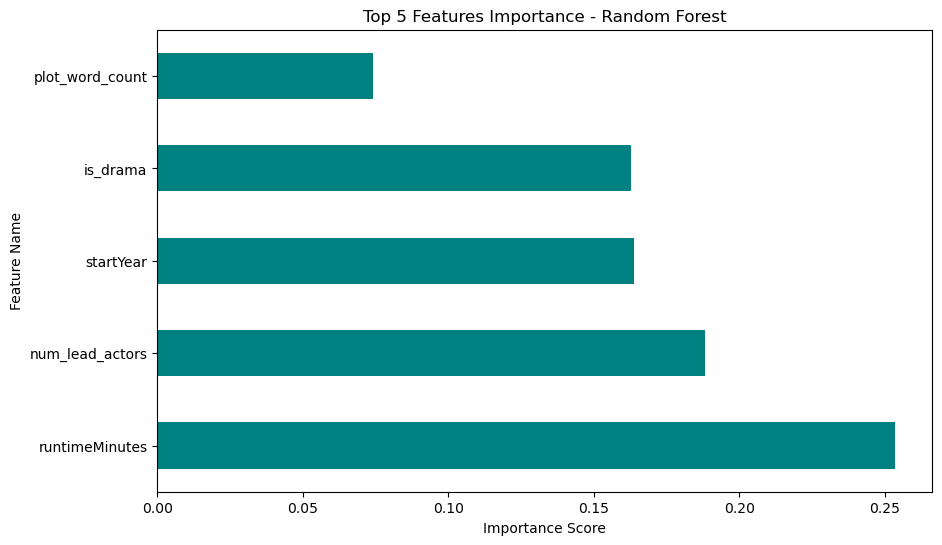

In [63]:
model_rf = rf_pipeline2.named_steps['model']
feature_names = rf_pipeline2.named_steps['preprocessor'].get_feature_names_out()

importances_rf = pd.Series(model_rf.feature_importances_, index=feature_names)

top_5_rf = importances_rf.sort_values(ascending=False).head(5)

print(top_5_rf)

plt.figure(figsize=(10, 6))
top_5_rf.plot(kind='barh', color='teal')
plt.title('Top 5 Features Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [64]:
features = ['runtimeMinutes', 'num_lead_actors', 'startYear', 'is_drama', 'plot_word_count']

for col in features:
    X_train[col] = X_train[col].astype(float)

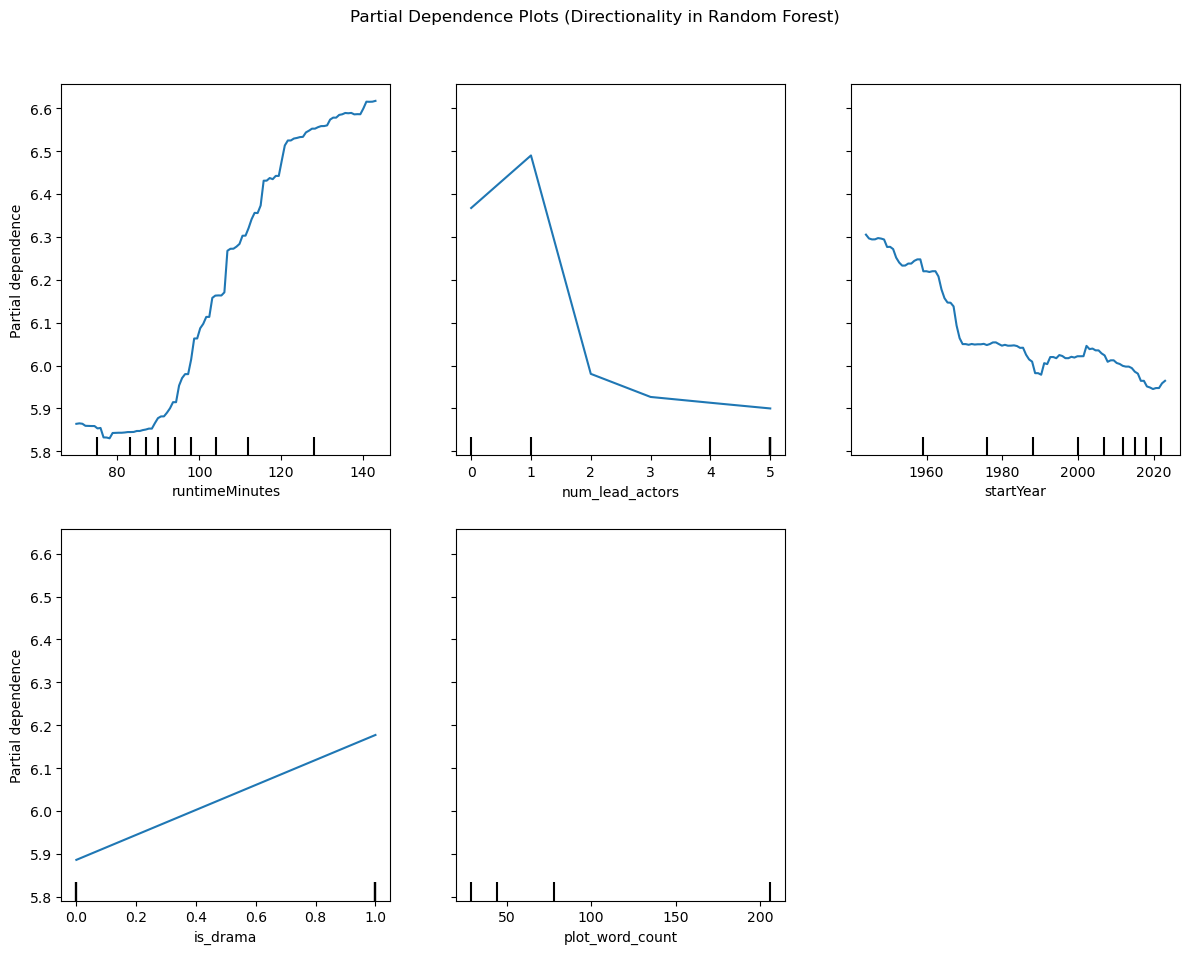

In [65]:
from sklearn.inspection import PartialDependenceDisplay

# יצירת גרפים עבורם
fig, ax = plt.subplots(figsize=(12, 10))
PartialDependenceDisplay.from_estimator(rf_pipeline2, X_train, features, ax=ax)
plt.suptitle("Partial Dependence Plots (Directionality in Random Forest)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## השוואה בין הפיצרים המשפיעים על כל מודל

In [66]:
comparison_df = pd.DataFrame({
    'ElasticNet_Importance': top_5_features,
    'RandomForest_Importance': top_5_rf
})

print(comparison_df)

                      ElasticNet_Importance  RandomForest_Importance
is_drama                           0.312231                 0.162752
is_english                        -0.143912                      NaN
max_actor_experience              -0.128403                      NaN
num_lead_actors                   -0.266900                 0.188194
plot_word_count                         NaN                 0.074202
runtimeMinutes                     0.205732                 0.253653
startYear                               NaN                 0.163689


# סעיף 6

In [67]:
X_train_processed = rf_pipeline2.named_steps['preprocessor'].transform(X_train)
feature_names = rf_pipeline2.named_steps['preprocessor'].get_feature_names_out()
results_table = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
results_table['Actual_Value'] = y_train
results_table['Predicted_Value'] = y_pred_cv

In [ ]:
print(len(results_table))

115560


In [ ]:
display(results_table.head(13))

,avg_actor_experience,max_actor_experience,sum_actor_experience,startYear,runtimeMinutes,plot_word_count,decade,duration_category,num_lead_actors,is_english,is_drama,is_us,Actual_Value,Predicted_Value
0,-0.414146,-0.454267,-0.381780,-0.175307,-0.383642,-0.211728,-0.118344,0.428365,0.600033,0.0,1.0,0.0,6.6,5.913011
1,-0.437500,-0.049545,-0.406065,1.043151,-0.562638,-0.211728,1.050099,-1.218459,0.600033,0.0,1.0,0.0,6.1,5.734672
2,0.052929,-0.100135,0.103928,0.335660,0.153347,-0.211728,0.271137,0.428365,0.600033,0.0,0.0,0.0,6.1,5.559913
3,-0.297377,-0.302496,-0.308923,0.532185,-0.607387,-0.211728,0.660618,-1.218459,-1.911313,0.0,0.0,0.0,7.0,6.632682
4,-0.297377,-0.302496,-0.308923,-0.175307,3.196281,-0.211728,-0.118344,2.075189,-1.911313,0.0,0.0,0.0,9.2,7.031913
5,-0.787805,-0.808399,-0.867487,0.846626,-0.517889,-0.211728,0.660618,-1.218459,-1.409044,0.0,0.0,0.0,7.3,6.823852
6,1.033785,1.265803,1.123915,-2.022646,-0.696885,-0.211728,-2.065749,-1.218459,0.600033,0.0,0.0,0.0,6.3,6.162079
7,-0.414146,-0.504857,-0.381780,0.571490,-0.786383,-0.211728,0.660618,-1.218459,0.600033,0.0,1.0,0.0,6.3,5.886607
8,-0.110547,-0.403677,-0.066069,0.964541,1.406320,-0.211728,1.050099,0.428365,0.600033,0.0,0.0,0.0,5.8,6.051754
9,0.963724,0.506948,1.051058,-0.253917,0.377092,-0.211728,-0.118344,0.428365,0.600033,1.0,0.0,0.0,6.8,6.027099


## נחלק לארצות הברית ולא ארצות הברית

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
us_df = results_table[results_table['is_us'] == 1]
non_us_df = results_table[results_table['is_us'] == 0]

mae_us = mean_absolute_error(us_df['Actual_Value'], us_df['Predicted_Value'])
rmse_us = np.sqrt(mean_squared_error(us_df['Actual_Value'], us_df['Predicted_Value']))

mae_non_us = mean_absolute_error(non_us_df['Actual_Value'], non_us_df['Predicted_Value'])
rmse_non_us = np.sqrt(mean_squared_error(non_us_df['Actual_Value'], non_us_df['Predicted_Value']))

print(f"US: MAE = {mae_us:.4f}, RMSE = {rmse_us:.4f}")
print(f"Non-US: MAE = {mae_non_us:.4f}, RMSE = {rmse_non_us:.4f}")

US: MAE = 0.7617, RMSE = 1.0137
Non-US: MAE = 0.9415, RMSE = 1.2218


Performance by Region:


,MAE,RMSE
US,0.761699,1.013726
Non-US,0.941475,1.221848


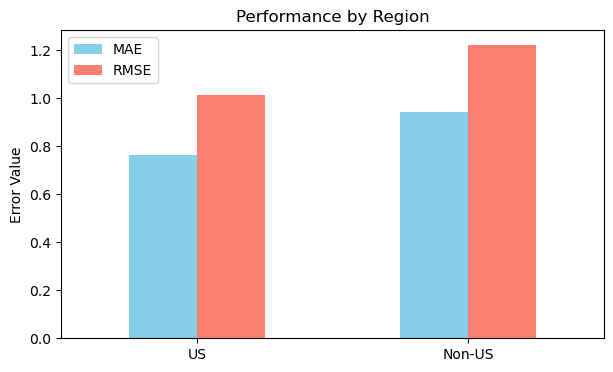

In [ ]:
metrics_us = {'MAE': mae_us, 'RMSE': rmse_us}
metrics_non_us = {'MAE': mae_non_us, 'RMSE': rmse_non_us}

# יצירת טבלה ל-US
df_us_viz = pd.DataFrame([metrics_us, metrics_non_us], index=['US', 'Non-US'])
print("Performance by Region:")
display(df_us_viz)


df_us_viz.plot(kind='bar', figsize=(7, 4), color=['skyblue', 'salmon'])
plt.title('Performance by Region')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(X_train.columns)

Index(['startYear', 'lead_actors_ids', 'runtimeMinutes', 'num_lead_actors',
       'duration_category', 'plot_word_count', 'is_english', 'is_drama',
       'is_us', 'decade'],
      dtype='object')


In [ ]:
print(results_table.columns)

Index(['avg_actor_experience', 'max_actor_experience', 'sum_actor_experience',
       'startYear', 'runtimeMinutes', 'plot_word_count', 'decade',
       'duration_category', 'num_lead_actors', 'is_english', 'is_drama',
       'is_us', 'Actual_Value', 'Predicted_Value'],
      dtype='object')


In [ ]:
results_table['original_decade'] = X_train['decade'].values

In [ ]:

decade_1900 = results_table[results_table['original_decade'] == 1900]
decade_1990 = results_table[results_table['original_decade'] == 1990]
decade_2010 = results_table[results_table['original_decade'] == 2010]
decade_2020 = results_table[results_table['original_decade'] == 2020]

def get_metrics(df):
    mae = mean_absolute_error(df['Actual_Value'], df['Predicted_Value'])
    rmse = np.sqrt(mean_squared_error(df['Actual_Value'], df['Predicted_Value']))
    return mae, rmse

decades_list = [
    ("1900", decade_1900),
    ("1990", decade_1990),
    ("2010", decade_2010),
    ("2020", decade_2020)
]

for name, decade_data in decades_list:
    if len(decade_data) > 0:
        mae, rmse = get_metrics(decade_data)
        print(f"Decade {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")
    else:
        print(f"Decade {name}: No data available")

Decade 1900: MAE = 1.4110, RMSE = 1.7264
Decade 1990: MAE = 0.8809, RMSE = 1.1169
Decade 2010: MAE = 0.9870, RMSE = 1.2866
Decade 2020: MAE = 1.0489, RMSE = 1.3632


Decade 1900: MAE = 1.4110, RMSE = 1.7264
Decade 1990: MAE = 0.8809, RMSE = 1.1169
Decade 2010: MAE = 0.9870, RMSE = 1.2866
Decade 2020: MAE = 1.0489, RMSE = 1.3632


,Decade,MAE,RMSE
0,1900,1.410973,1.726376
1,1990,0.880896,1.116903
2,2010,0.986963,1.286650
3,2020,1.048878,1.363197


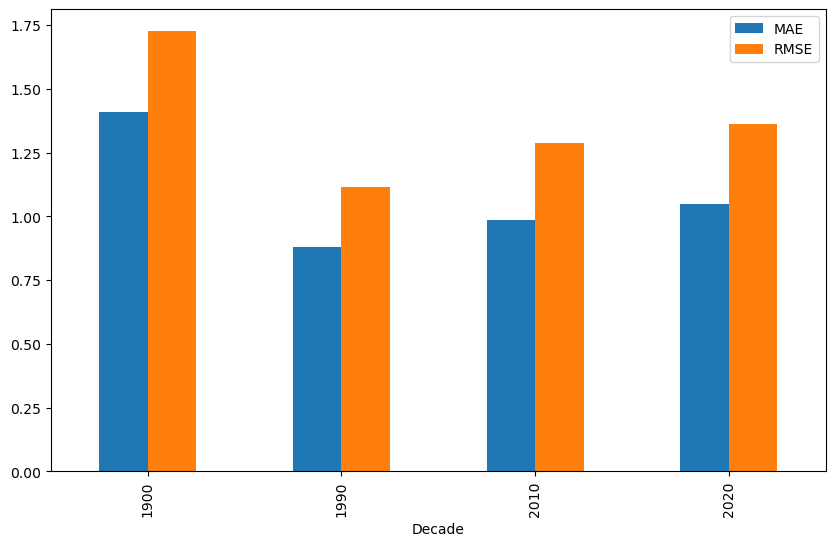

In [ ]:
results_table['original_decade'] = results_table['original_decade'].fillna(0).astype(int)
decades_to_check = [1900, 1990, 2010, 2020]
results_list = []

for decade in decades_to_check:
    decade_df = results_table[results_table['original_decade'] == decade]
    
    if not decade_df.empty:
        mae, rmse = get_metrics(decade_df)
        print(f"Decade {decade}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")
        results_list.append({'Decade': str(decade), 'MAE': mae, 'RMSE': rmse})
    else:
        print(f"Decade {decade}: No data available")

results_df = pd.DataFrame(results_list)
if not results_df.empty:
    display(results_df)
    results_df.plot(x='Decade', y=['MAE', 'RMSE'], kind='bar', figsize=(10, 6))
    plt.show()

## ציון על כל הדאטה

In [ ]:
total_mae, total_rmse = get_metrics(results_table)

print(f"Total Model Performance:")
print(f"MAE = {total_mae:.4f}")
print(f"RMSE = {total_rmse:.4f}")

Total Model Performance:
MAE = 0.9115
RMSE = 1.1897


In [ ]:
total_mae, total_rmse = get_metrics(results_table)

data = [
    {"Category": "US", "RMSE": 1.0137},
    {"Category": "Non-US", "RMSE": 1.2218},
    {"Category": "1900", "RMSE": 1.7264},
    {"Category": "1990", "RMSE": 1.1169},
    {"Category": "2010", "RMSE": 1.2866},
    {"Category": "2020", "RMSE": 1.3632}
]

df_results = pd.DataFrame(data)
df_results['Deviation_Percent'] = ((df_results['RMSE'] - total_rmse) / total_rmse) * 100

print(f"Total Model RMSE: {total_rmse:.4f}")
print("-" * 45)
print(df_results)

Total Model RMSE: 1.1897
---------------------------------------------
  Category    RMSE  Deviation_Percent
0       US  1.0137         -14.795609
1   Non-US  1.2218           2.695793
2     1900  1.7264          45.108869
3     1990  1.1169          -6.121353
4     2010  1.2866           8.142418
5     2020  1.3632          14.580868


### ניתן לראות שבחתך של עשור 1990 המודל הכי פחות מדויק

### נבדוק אם זה אולי מהסיבה שיש על עשור זה פחות בדאטה המקורי

In [ ]:
print(df.columns)

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot'],
      dtype='object')


In [ ]:
df['Decade'] = (df['startYear'] // 10) * 10


print("--- כמות סרטים בכל עשור ---")
print(df['Decade'].value_counts().sort_index())

--- כמות סרטים בכל עשור ---
Decade
0.0           1
1900.0        2
1910.0      171
1920.0      785
1930.0     3121
1940.0     3292
1950.0     4602
1960.0     6208
1970.0     7969
1980.0     9631
1990.0    10213
2000.0    17555
2010.0    33605
2020.0    18405
Name: count, dtype: int64


#  לצורך טעינת המודל ActorExperienceTransformer יש להריץ את המחלקה 

In [ ]:
import joblib
joblib.dump(full_pipeline, 'model.pkl')

['model.pkl']

In [ ]:
!pip list --format=freeze > requirements.txt